# Plan d'implémentation pour le TP des métaheuristiques par voisinage
Dans ce TP, nous allons implémenter et comparer différentes variantes d'algorithmes métaheuristiques basés sur le principe de recherche locale par voisinage, appliqués au problème de la coloration de graphe.

Nous allons coder :

     1. Récuit Simulé Classique (RS)
     2. Récuit Simulé Adaptatif (RSA)
     3. Récuit Simulé à Température Oscillante (RSO)
     4. Récuit Simulé Parallèle (RSP)
     5. Recherche Tabou (Tabu Search)

Et comme proposition innovante, nous implémentons aussi :

     6. GSAT amélioré (GPCG_Improved) comme métaheuristique hybride.

Chaque méthode sera testée sur des graphes issus des benchmarks DIMACS.

# Auto-ajustement des paramètres (Grid Search)
Pour améliorer la qualité des solutions et optimiser les performances du Recuit Simulé (notamment en les versions parallèle coopérative et a rechauffement), nous avons implémenté une fonction d’auto-ajustement des paramètres : auto_param_tuning.

Cette fonction repose sur une stratégie de grid search classique : elle teste systématiquement plusieurs combinaisons de trois paramètres principaux :

la température initiale (initial_temp)

le taux de refroidissement (cooling_rate)

le nombre maximal d’itérations (max_iter)

Pour chaque combinaison, elle exécute l’algorithme et enregistre le nombre de conflits restants ainsi que le temps d’exécution.

Afin de sélectionner la meilleure configuration pour un graphe donné, on utilise une fonction objectif multi-critères qui combine :

le nombre de conflits (pondéré à 70%)

le temps d'exécution (pondéré à 30%)

Ces deux métriques sont normalisées pour rendre la comparaison équitable. La combinaison de paramètres avec le meilleur score pondéré est retenue comme la plus adaptée pour ce graphe.

Cette approche permet de trouver de bons paramètres dynamiquement, sans avoir à les ajuster manuellement pour chaque instance, ce qui rend notre solution plus robuste et générale.

# Fonctions Utilitaires Communes
cette section contient un ensemble de fonctions utilitaires indispensables à toutes les variantes d’algorithmes que nous allons implémenter dans ce TP.

Exemple de ce que peuton trouver la dessus:
1. 📂 `lire_graphe_triangulaire()` : lit un graphe au format DIMACS (.col) et le convertit en une matrice triangulaire inférieure.
2. 🧭 `neighbors_of()` : retourne les voisins d’un sommet donné à partir de la matrice triangulaire.
3. 🎲 `initialize_solution()` : génère une solution initiale aléatoire (coloration aléatoire).
4. ⚠️ `calculate_conflicts()` : calcule le nombre de conflits de coloration pour une solution donnée. (ceci étant le nombre de paires de sommets adjacents (liés par une arête) ayant la même couleur, ce qui viole la contrainte de la coloration propre d’un graphe.)

In [2]:
import random
import math
import copy
import time
import numpy as np
import requests
import multiprocessing as mp
import matplotlib.pyplot as plt

In [3]:
#fonction recuperation du graphe du website DMACS
def lire_graphe_triangulaire(url_fichier,is_url):
    """
    Lit un fichier DIMACS et convertit le graphe en une matrice triangulaire inférieure.

    :param url_fichier: URL du fichier .col contenant le graphe
    :return: Matrice triangulaire inférieure sous forme de liste de listes
    """
    lignes = []
    if(is_url):
      response = requests.get(url_fichier)
      text = response.text
      lignes = text.split('\n')
    else:
      with open(url_fichier, 'r') as f:
        lignes = f.readlines()

    nb_sommets = 0
    aretes = []

    for ligne in lignes:
        ligne = ligne.strip()
        if ligne.startswith('p'):
            _, _, nb_sommets, _ = ligne.split()
            nb_sommets = int(nb_sommets)
        elif ligne.startswith('e'):
            _, sommet1, sommet2 = ligne.split()
            sommet1, sommet2 = int(sommet1), int(sommet2)
            aretes.append((sommet1, sommet2))

    # Création de la matrice triangulaire inférieure
    matrice_triangulaire = [[0] * (i + 1) for i in range(nb_sommets)]
    for sommet1, sommet2 in aretes:
        sommet1 -= 1  # Ajustement des indices (DIMACS commence à 1)
        sommet2 -= 1
        if sommet1 > sommet2:
            matrice_triangulaire[sommet1][sommet2] = 1
        else:
            matrice_triangulaire[sommet2][sommet1] = 1

    return matrice_triangulaire, nb_sommets

In [4]:
def neighbors_of(vertex, matrice):
  '''
  returns the set of neighbors of :vertex
  '''
  neighbors = set()
  n_vertices = len(matrice)
  for possible_neighbor in range(0, vertex):
    if matrice[vertex][possible_neighbor] == 1:
      neighbors.add(possible_neighbor)
  for possible_neighbor in range(vertex + 1, n_vertices):
    if matrice[possible_neighbor][vertex] == 1:
      neighbors.add(possible_neighbor)
  return neighbors


In [5]:
def get_colors(vertices, coloring):
  '''
  return set of distinct colors used only by :vertices in the graph colored
  by :coloring
  '''
  color_set = set()
  for vertex in vertices:
    if coloring[vertex] not in color_set:
      color_set.add(coloring[vertex])
  return color_set

In [6]:
#solution aléatoire (non basé sur une heuristique ou quoi que ce soit)
def initialize_solution(num_vertices, chromatic_number):
    """
    Generates a random vertex coloring.

    :param num_vertices: Number of vertices in the graph
    :param chromatic_number: Graph's chromatic number
    :return: Random initial coloring
    """
    return [random.randint(1, chromatic_number) for _ in range(num_vertices)]

In [7]:
def calculate_conflicts(adj_matrix, num_vertices, coloring):
    """
    Calculates the number of coloring conflicts (edges with same color at both ends).

    :param adj_matrix: Graph adjacency matrix
    :param num_vertices: Number of vertices in the graph
    :param coloring: Current vertex coloring
    :return: Total number of conflicts
    """
    conflicts = 0
    for i in range(num_vertices):
        for j in range(i):
            if adj_matrix[i][j] == 1 and coloring[i] == coloring[j]:
                conflicts += 1
    return conflicts


In [8]:
def generate_neighbor(coloring, chromatic_number):
    """
    Generates a neighboring solution by randomly changing one vertex's color.

    :param coloring: Current coloring
    :param chromatic_number: Number of available colors
    :return: New neighboring coloring
    """
    neighbor = coloring.copy()
    vertex = random.randint(0, len(coloring) - 1)
    current_color = neighbor[vertex]

    # Choose a new different color
    new_color = current_color
    while new_color == current_color:
        new_color = random.randint(1, chromatic_number)

    neighbor[vertex] = new_color
    return neighbor

# Le Récuit Simulé
Utilise une température initiale élevée, puis applique un refroidissement exponentiel à chaque itération.

Il faut comprendre les paramètres pour pouvoir ensuite les calibrer et les ajuster pour avoir les meilleures solutions :
T_initial (température initiale) : plus elle est élevée, plus la recherche est exploratoire au début.

alpha : facteur de refroidissement, typiquement entre 0.8 et 0.99.

max_iter : limite d’itérations.

donc plus T_initial est grande → plus de sauts possibles au début → diversification.

si alpha est trop petit, la température baisse vite → risque de piéger dans un optimum local.

il faut équilibrer exploration (début) et exploitation (fin)

il faut savoir que : On ne doit jamais retourner une solution avec des conflits > 0. Si des conflits subsistent, on réessaye automatiquement avec plus de couleurs et on s'arrete dès qu'une solution valide (sans conflit) est trouvée.

In [9]:
def recuit_simule(adj_matrix, num_vertices, chromatic_number, initial_temp=1000, cooling_rate=0.003, max_iterations=1000, max_color_increase=20):
    """
    Simulated Annealing with auto-correction: if no valid coloring is found (conflicts > 0),
    the algorithm retries with more colors (up to +max_color_increase).
    """

    start_time_total = time.time()

    for extra_colors in range(0, max_color_increase + 1):
        k = chromatic_number + extra_colors  # number of colors this round

        current_solution = initialize_solution(num_vertices, k)
        current_energy = calculate_conflicts(adj_matrix, num_vertices, current_solution)

        best_solution = current_solution.copy()
        best_energy = current_energy
        energy_history = [current_energy]
        temp = initial_temp

        for iteration in range(max_iterations):
            if best_energy == 0:  # Valid coloring found
                end_time = time.time()
                return best_solution, best_energy, energy_history, end_time - start_time_total

            # Generate neighbor
            neighbor = generate_neighbor(current_solution, k)
            neighbor_energy = calculate_conflicts(adj_matrix, num_vertices, neighbor)

            # Accept or reject neighbor
            delta = neighbor_energy - current_energy
            if delta < 0 or random.random() < math.exp(-delta / temp):
                current_solution = neighbor
                current_energy = neighbor_energy

                if current_energy < best_energy:
                    best_solution = current_solution.copy()
                    best_energy = current_energy

            energy_history.append(current_energy)
            temp *= 1 - cooling_rate  # temperature decay

        # If we get here, we did not find a valid solution → try again with more colors
        print(f"[INFO] Retry with {k+1} colors (still {best_energy} conflicts).")

    # Final fallback if no valid solution is found
    end_time = time.time()
    return best_solution, best_energy, energy_history, end_time - start_time_total

In [10]:
# Dictionnaire des graphes et leurs bornes chromatiques connues
graphs_best = {
    "dsjc125.9": "44",
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "r250.1": "8",
    "flat300_28_0": "28/28",
    "le450_25c": "25/25"
}

# Test du recuit simulé avec réchauffement sur chaque graphe
for graph, best in graphs_best.items():
    print("\n\n========================")
    print(f"Graph: {graph} | Best known: {best}")
    print("========================")

    # Lecture du graphe depuis l'URL
    matx, n = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col", is_url=True)

    # Définir un nombre raisonnable de couleurs (par exemple : best connu + marge)
    nb_couleurs = int(best.split("/")[0]) + 5

    # Appel de l'algorithme
    solution_finale, conflits, conflits_logs, temps = recuit_simule(
        adj_matrix=matx,
        num_vertices=n,
        chromatic_number=nb_couleurs,
        initial_temp=1000,
        cooling_rate=0.003,
        max_iterations=10000
    )

    # Affichage des résultats
    print(f"Nombre de conflits : {conflits}")
    print(f"Journal des conflits : {conflits_logs}")
    print(f"Nombre de couleurs utilisées : {len(set(solution_finale))}")
    print(f"Temps d'exécution : {temps:.4f} secondes")




Graph: dsjc125.9 | Best known: 44
[INFO] Retry with 50 colors (still 14 conflicts).
[INFO] Retry with 51 colors (still 15 conflicts).
[INFO] Retry with 52 colors (still 12 conflicts).
[INFO] Retry with 53 colors (still 15 conflicts).
[INFO] Retry with 54 colors (still 7 conflicts).
[INFO] Retry with 55 colors (still 6 conflicts).
[INFO] Retry with 56 colors (still 5 conflicts).
[INFO] Retry with 57 colors (still 5 conflicts).
[INFO] Retry with 58 colors (still 3 conflicts).
[INFO] Retry with 59 colors (still 3 conflicts).
[INFO] Retry with 60 colors (still 5 conflicts).
[INFO] Retry with 61 colors (still 2 conflicts).
[INFO] Retry with 62 colors (still 2 conflicts).
Nombre de conflits : 0
Journal des conflits : [107, 108, 107, 106, 106, 107, 107, 107, 107, 112, 109, 109, 108, 110, 109, 108, 110, 109, 109, 107, 111, 113, 112, 111, 109, 109, 107, 105, 109, 112, 114, 110, 113, 113, 115, 115, 114, 111, 107, 104, 102, 103, 106, 108, 108, 109, 108, 112, 112, 110, 107, 106, 108, 107, 109, 1

# Le Récuit Simulé Adaptatif

In [11]:
#meilleure exploration(diversification) au début: à cause d'une température élevée maintenue plus longtemps si les solutions stagnent
# meilleure exploitation bers la fin: le voisinage se resserre autour des bonnes zones (intensification locale)
# et parceque il est dynamique: il s’autorégule, donc moins besoin de fine-tune la température initiale et la décroissance
# il évolue selon ce qui'il observe sur lq qualité des solutions
# la température ne diminue pas de manière fixe mais s'adapte selon le progrés // qualité des solutions
# la stratégie de génération de voisinage peut aussi changer dynamiquement
def recuit_simule_adaptatif(
    adj_matrix, num_vertices, chromatic_number,
    T_initial=1000, T_min=0.01,
    max_iter=10000, stagnation_threshold=100,
    alpha=0.95, max_color_increase=20
):
    """
    Recuit Simulé Adaptatif avec auto-correction si des conflits persistent après la phase principale.
    Relance automatiquement avec plus de couleurs jusqu'à obtenir une solution valide (conflict-free).
    """

    start_total = time.time()

    for extra_colors in range(max_color_increase + 1):
        k = chromatic_number + extra_colors

        # Initialisation
        current_solution = initialize_solution(num_vertices, k)
        current_cost = calculate_conflicts(adj_matrix, num_vertices, current_solution)

        best_solution = current_solution.copy()
        best_cost = current_cost

        T = T_initial
        no_improvement = 0

        for iteration in range(max_iter):
            # Arrêt immédiat si solution valide
            if best_cost == 0:
                end_total = time.time()
                return best_solution, best_cost, end_total - start_total

            # Génération d’un voisin
            neighbor = generate_neighbor(current_solution, k)
            neighbor_cost = calculate_conflicts(adj_matrix, num_vertices, neighbor)

            # Acceptation selon critère
            delta = neighbor_cost - current_cost
            if delta < 0 or random.random() < math.exp(-delta / T):
                current_solution = neighbor
                current_cost = neighbor_cost

                if current_cost < best_cost:
                    best_solution = current_solution.copy()
                    best_cost = current_cost
                    no_improvement = 0
                else:
                    no_improvement += 1
            else:
                no_improvement += 1

            # Refroidissement adaptatif
            if no_improvement >= stagnation_threshold:
                T *= alpha  # accélère le refroidissement si stagnation
                no_improvement = 0
            else:
                T *= 0.99  # refroidissement normal

            # Température minimale atteinte
            if T < T_min:
                break

        # Si toujours des conflits, essayer avec plus de couleurs
        print(f"[INFO] Conflits restants ({best_cost}) → nouvelle tentative avec {k+1} couleurs.")

    # Retour final si on atteint max_color_increase et qu'on n'a toujours pas 0 conflit
    end_total = time.time()
    return best_solution, best_cost, end_total - start_total

In [12]:
# Dictionnaire des graphes et leurs bornes chromatiques connues
graphs_best = {
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "r250.1": "8",
    "flat300_28_0": "28/28",
}

# Test du recuit simulé avec réchauffement sur chaque graphe
for graph, best in graphs_best.items():
    print("\n\n========================")
    print(f"Graph: {graph} | Best known: {best}")
    print("========================")

    # Lecture du graphe depuis l'URL
    matx, n = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col", is_url=True)

    # Définir un nombre raisonnable de couleurs (par exemple : best connu + marge)
    nb_couleurs = int(best.split("/")[0]) + 5

    # Appel de l'algorithme
    solution_finale, conflits, temps = recuit_simule_adaptatif(
                adj_matrix=matx,
                num_vertices=n,
                chromatic_number=nb_couleurs,
                T_initial=100,
                alpha=0.95
            )

    # Affichage des résultats
    print(f"Nombre de conflits : {conflits}")
    print(f"Nombre de couleurs utilisées : {len(set(solution_finale))}")
    print(f"Temps d'exécution : {temps:.4f} secondes")



Graph: dsjc125.1 | Best known: 5
[INFO] Conflits restants (4) → nouvelle tentative avec 11 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 12 couleurs.
[INFO] Conflits restants (4) → nouvelle tentative avec 13 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 14 couleurs.
[INFO] Conflits restants (1) → nouvelle tentative avec 15 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 16 couleurs.
Nombre de conflits : 0
Nombre de couleurs utilisées : 16
Temps d'exécution : 3.4719 secondes


Graph: dsjc250.1 | Best known: 8
[INFO] Conflits restants (89) → nouvelle tentative avec 14 couleurs.
[INFO] Conflits restants (61) → nouvelle tentative avec 15 couleurs.
[INFO] Conflits restants (61) → nouvelle tentative avec 16 couleurs.
[INFO] Conflits restants (47) → nouvelle tentative avec 17 couleurs.
[INFO] Conflits restants (39) → nouvelle tentative avec 18 couleurs.
[INFO] Conflits restants (50) → nouvelle tentative avec 19 couleurs.
[INFO] Conflits

# Le Recuit Simulé Parallèle

In [13]:
def worker_process(adj_matrix, num_vertices, chromatic_number, initial_temp, cooling_rate, max_iterations, shared_best):
    """
    Processus de travail pour le recuit simulé coopératif.
    Chaque processus tente d'améliorer la solution partagée.

     :param adj_matrix: matrice d’adjacence
    :param num_vertices: nombre de sommets
    :param chromatic_number: nombre de couleurs disponibles
    :param initial_temp: température initiale
    :param cooling_rate: taux de refroidissement
    :param max_iterations: nombre maximum d’itérations
    :param result_queue: file de sortie pour renvoyer les résultats au processus principal
    """
    solution, energy, *_ = recuit_simule(
        adj_matrix, num_vertices, chromatic_number,
        initial_temp, cooling_rate, max_iterations
    )

    # Mise à jour de la meilleure solution trouvée globalement
    if energy < shared_best["energy"]:
        shared_best["solution"] = solution
        shared_best["energy"] = energy


In [14]:
def calculate_energy(adj_matrix, solution):
    n = len(solution)
    energy = 0
    for i in range(n):
        for j in range(n):
            if i < len(adj_matrix) and j < len(adj_matrix[i]):
                if adj_matrix[i][j] == 1 and solution[i] == solution[j]:
                    energy += 1
    return energy

def parallel_simulated_annealing_cooperative(adj_matrix, num_vertices, chromatic_number,
                                              initial_temp=100, cooling_rate=0.003,
                                              num_workers=4, max_iterations=10000):
    """
    Version coopérative parallèle du recuit simulé pour la coloration de graphe.
    Les processus partagent et mettent à jour la meilleure solution globalement.

    Version parallèle du recuit simulé pour la coloration de graphe.

    :param adj_matrix: Matrice d’adjacence (triangulaire inférieure)
    :param num_vertices: Nombre de sommets du graphe
    :param chromatic_number: Nombre de couleurs à utiliser
    :param initial_temp: Température initiale
    :param cooling_rate: Taux de refroidissement (entre 0 et 1)
    :param num_workers: Nombre de processus parallèles à exécuter
    :param max_iterations: Nombre maximum d’itérations par processus
    :return: (meilleure solution, nombre de conflits, temps d'exécution)

    Remarque :
     Les valeurs choisies pour les paramètres (initial_temp=100, cooling_rate=0.003,
    num_workers=4, max_iterations=10000) sont le résultat de plusieurs tests empiriques.
    Lors de l’expérimentation, nous avons fait varier un paramètre à la fois tout en gardant
    les autres constants, afin d’analyser son influence sur les performances de l’algorithme.
    Cette approche a permis d’identifier une combinaison de paramètres menant à des solutions
    optimales ou quasi-optimales dans un temps raisonnable.
    """
    start_time = time.time()
    manager = mp.Manager()
    shared_best = manager.dict()
    shared_best["solution"] = [random.randint(0, chromatic_number - 1) for _ in range(num_vertices)]
    shared_best["energy"] = calculate_energy(adj_matrix, shared_best["solution"])

    processes = []

    for _ in range(num_workers):
        p = mp.Process(target=worker_process, args=(
            adj_matrix, num_vertices, chromatic_number,
            initial_temp, cooling_rate, max_iterations, shared_best
        ))
        p.start()
        processes.append(p)

    for p in processes:
        p.join()

    end_time = time.time()
    return shared_best["solution"], shared_best["energy"], end_time - start_time


In [17]:
import itertools

# Dictionnaire des graphes et leurs bornes chromatiques connues
graphs_best = {
    "dsjc125.1": "5",
    "r250.1": "8"
}

In [ ]:
def auto_param_tuning(graphs_best, test_graphs=None, weight_conf=0.7, weight_time=0.3):
    """
    Teste différentes combinaisons de paramètres pour chaque graphe.
    Sélectionne la meilleure combinaison basée sur une moyenne pondérée (conflits vs. temps).
    """

    initial_temps = [100, 500, 1000]
    cooling_rates = [0.001, 0.003, 0.005]
    max_iterations_list = [5000, 10000]
    num_workers = 4

    if test_graphs is None:
        test_graphs = list(graphs_best.keys())

    for graph in test_graphs:
        print("\n\n========================")
        print(f"Graph: {graph} | Best known: {graphs_best[graph]}")
        print("========================")

        matx, n = lire_graphe_triangulaire(
            f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col", is_url=True
        )
        chromatic_bound = int(graphs_best[graph].split("/")[0])
        chromatic_number = chromatic_bound + 5

        results = []

        for initial_temp, cooling_rate, max_iter in itertools.product(
            initial_temps, cooling_rates, max_iterations_list
        ):
            print(f"\n>> Test : T={initial_temp}, α={cooling_rate}, it={max_iter}")
            solution, nb_conflits, duree = parallel_simulated_annealing_cooperative(
                adj_matrix=matx,
                num_vertices=n,
                chromatic_number=chromatic_number,
                initial_temp=initial_temp,
                cooling_rate=cooling_rate,
                num_workers=num_workers,
                max_iterations=max_iter
            )
            print(f"Conflits: {nb_conflits}, Couleurs: {len(set(solution))}, Temps: {duree:.2f}s")

            results.append({
                "params": (initial_temp, cooling_rate, max_iter),
                "conflits": nb_conflits,
                "temps": duree
            })

        max_conf = max(r["conflits"] for r in results)
        min_conf = min(r["conflits"] for r in results)
        max_time = max(r["temps"] for r in results)
        min_time = min(r["temps"] for r in results)

        for r in results:
            r["norm_conf"] = 0 if max_conf == min_conf else (r["conflits"] - min_conf) / (max_conf - min_conf)
            r["norm_time"] = 0 if max_time == min_time else (r["temps"] - min_time) / (max_time - min_time)
            r["score"] = (weight_conf * r["norm_conf"]) + (weight_time * r["norm_time"])

        best_result = min(results, key=lambda r: r["score"])

        print(f"\n✅ Meilleur résultat pour {graph} (pondéré {weight_conf*100:.0f}% conflits / {weight_time*100:.0f}% temps) :")
        print(f"Conflits: {best_result['conflits']}")
        print(f"Paramètres: Temp={best_result['params'][0]}, Cooling={best_result['params'][1]}, Iter={best_result['params'][2]}")
        print(f"Temps d'exécution : {best_result['temps']:.2f} secondes")
        print(f"Score pondéré : {best_result['score']:.4f}")

auto_param_tuning(graphs_best, test_graphs=None, weight_conf=0.7, weight_time=0.3)

# Le Recuit Simulé à température oscillante (ou "Simulated Annealing with reheating")

In [ ]:
def recuit_simule_rechauffement(matrice, nb_sommets, nb_couleurs, T_init=100.0, alpha=0.95, beta=0.8,
                                iter_par_cycle=1000, max_cycles=100, seuil_rechauffement=15):
    """
    L’idée est d’utiliser une température oscillante : après plusieurs cycles sans amélioration,
    on « réchauffe » le système pour éviter de rester bloqué dans un minimum local.

    :param matrice: matrice triangulaire inférieure représentant le graphe
    :param nb_sommets: nombre total de sommets
    :param nb_couleurs: nombre maximum de couleurs autorisées
    :param T_init: température initiale du recuit
    :param alpha: facteur de refroidissement à chaque cycle
    :param beta: facteur de réchauffement (T = beta * T_init)
    :param iter_par_cycle: nombre d’itérations dans chaque cycle
    :param max_cycles: nombre maximum de cycles
    :param seuil_rechauffement: nombre de cycles sans amélioration avant réchauffement
    :return: meilleure solution trouvée, nombre de conflits associés
    """
    debut = time.time()  # Début du chronomètre
    solution = [random.randint(0, nb_couleurs - 1) for _ in range(nb_sommets)] #should be replaced withi initialize solution
    meilleure_solution = copy.deepcopy(solution)
    cout_solution = calculate_conflicts(matrice,nb_sommets,solution)
    meilleur_cout = cout_solution

    T = T_init
    pas_ameliore = 0
    for cycle in range(max_cycles):
        for _ in range(iter_par_cycle):
            voisin = generate_neighbor(solution, nb_couleurs)
            cout_voisin = calculate_conflicts(matrice,nb_sommets,solution)
            delta = cout_voisin - cout_solution

            if delta < 0 or random.random() < math.exp(-delta / T):
                solution = voisin
                cout_solution = cout_voisin

                if cout_solution < meilleur_cout:
                    meilleure_solution = copy.deepcopy(solution)
                    meilleur_cout = cout_solution
                    pas_ameliore = 0
                else:
                    pas_ameliore += 1

        T *= alpha
        if pas_ameliore >= seuil_rechauffement:
            T = beta * T_init
            pas_ameliore = 0

    fin = time.time()  # Fin du chronomètre
    temps_execution = fin - debut

    return meilleure_solution, meilleur_cout, temps_execution

 Lors de l'évaluation de l’effet des paramètres de l’algorithme de recuit simulé avec réchauffement, nous avons constaté les points suivants :


- Une température initiale "T_init" modérée améliore la qualité des solutions (atteindre des solutions avec moins de conflits car Une température trop basse limite l'exploration, tandis qu'une température trop élevée provoque trop d'acceptations aléatoires)

- Un Alpha élevé comme 0.99 permet à l’algorithme de continuer à explorer plus longtemps

- Un Beta modéré (environ 0.8) a donné les meilleurs résultats en termes de réduction des conflits.

- Lorsque le nombre d’itérations par cycle (iter_par_cycle) et nombre de cycles (max_cycles) sont trop élevés, le temps d’exécution augmente
    considérablement sans que la qualité des solutions ne s’améliore de façon significative.

- Un seuil de réchauffement trés bas trop bas provoque des réchauffements trop fréquents, alors qu’un seuil trop élevé empêche l’algorithme de sortir
d’un minimum local. Une valeur intermédiaire (comme 10) a offert un bon équilibre.

=== Meilleurs paramètres ===
- T_init : T=300
- max_cycles : Cycles=150
- iter : Iters=3000
- seuil : Seuil=10
- beta : β=0.9
- alpha : α=0.97

Remarque : les valeurs de "conflits" enregistrées ici correspondent aux conflits mesurés pendant la recherche
(durant les cycles et itérations du recuit simulé), et ne reflètent pas nécessairement l'état final de la solution.
La solution retournée à la fin est normalement valide (i.e., conflits finaux = 0).


======= GRAPHE dsjc250.1 =======


<ipython-input-6-1be2a14ae832>:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-6-1be2a14ae832>:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels, rotation=45, ha='right')


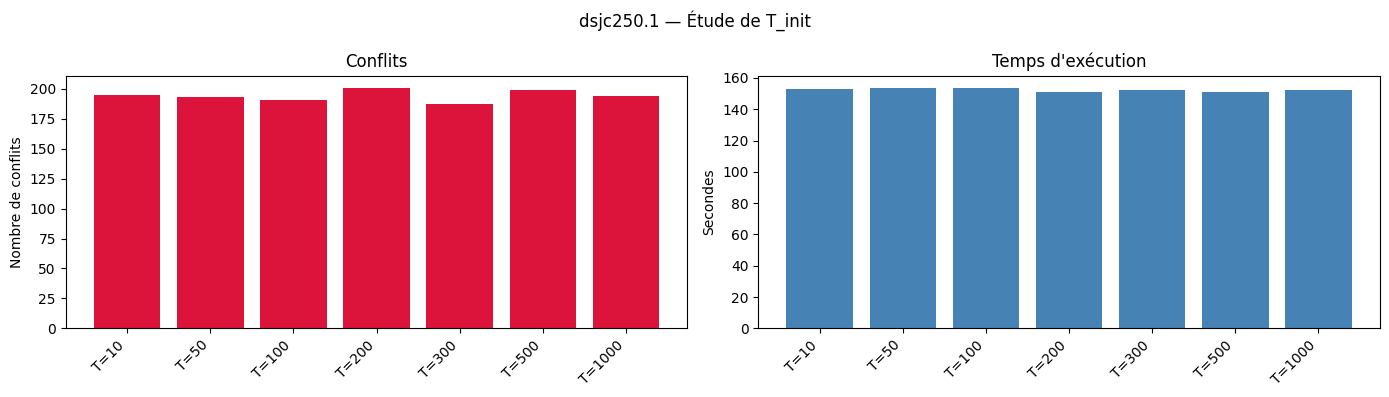

<ipython-input-6-1be2a14ae832>:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-6-1be2a14ae832>:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels, rotation=45, ha='right')


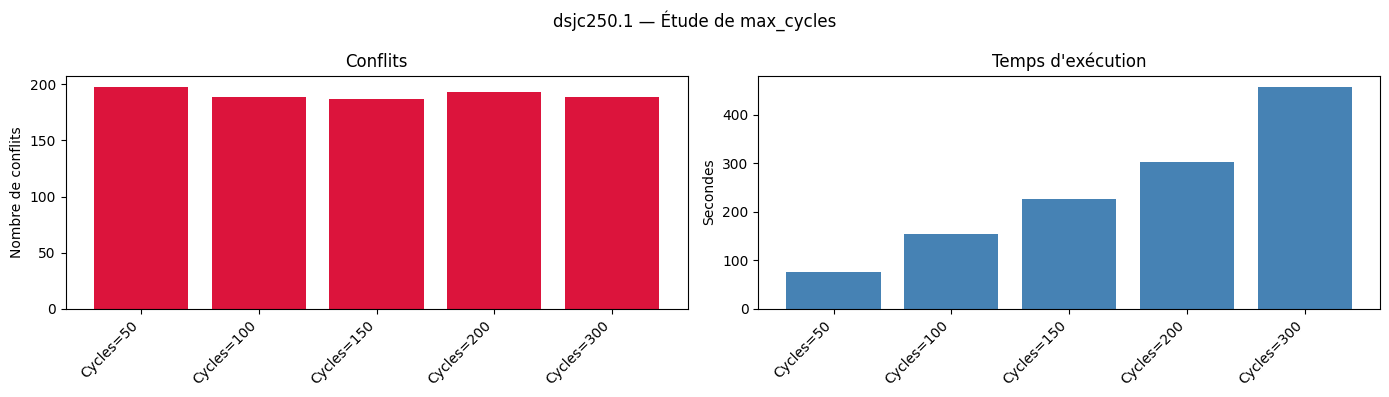

<ipython-input-6-1be2a14ae832>:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-6-1be2a14ae832>:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels, rotation=45, ha='right')


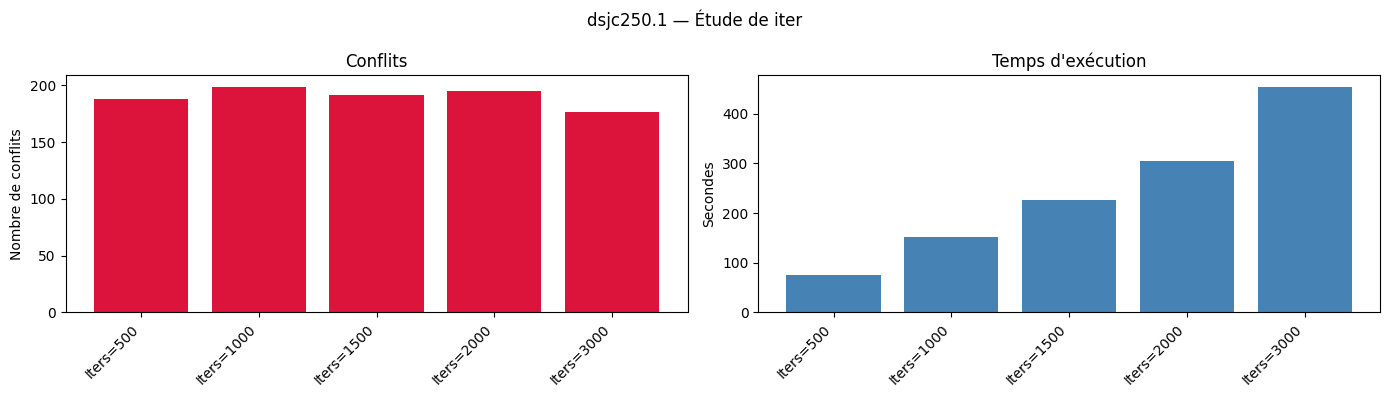

<ipython-input-6-1be2a14ae832>:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-6-1be2a14ae832>:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels, rotation=45, ha='right')


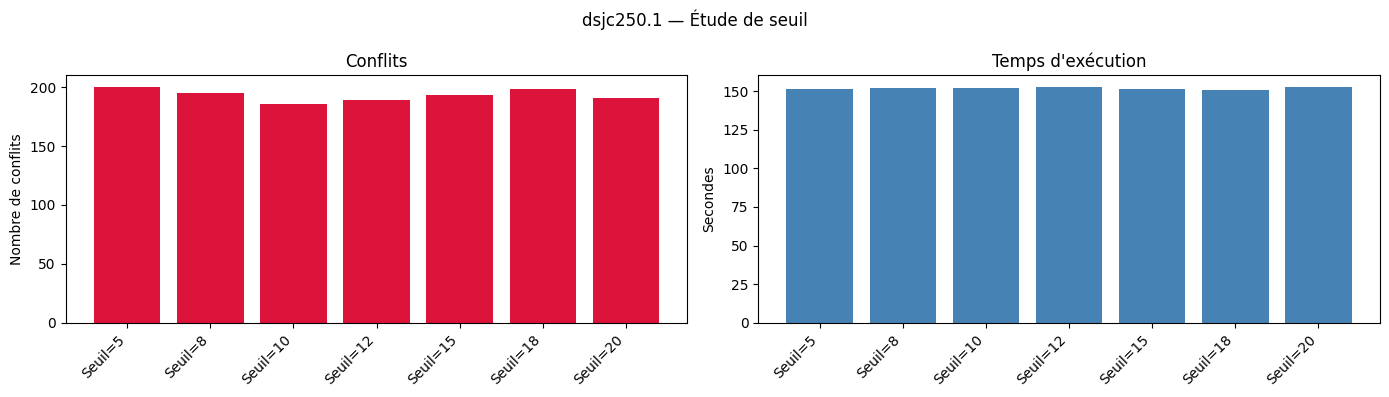

<ipython-input-6-1be2a14ae832>:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-6-1be2a14ae832>:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels, rotation=45, ha='right')


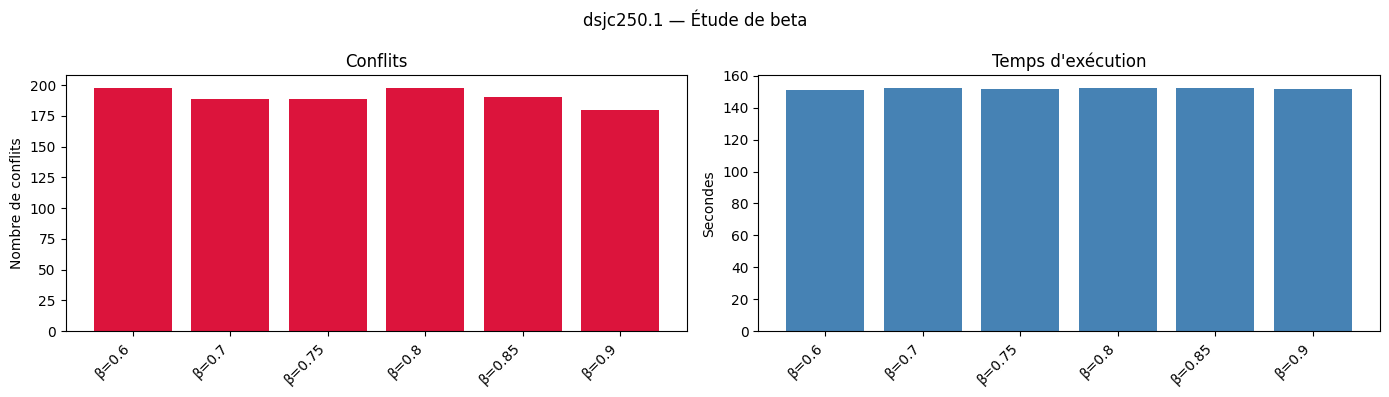

<ipython-input-6-1be2a14ae832>:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-6-1be2a14ae832>:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels, rotation=45, ha='right')


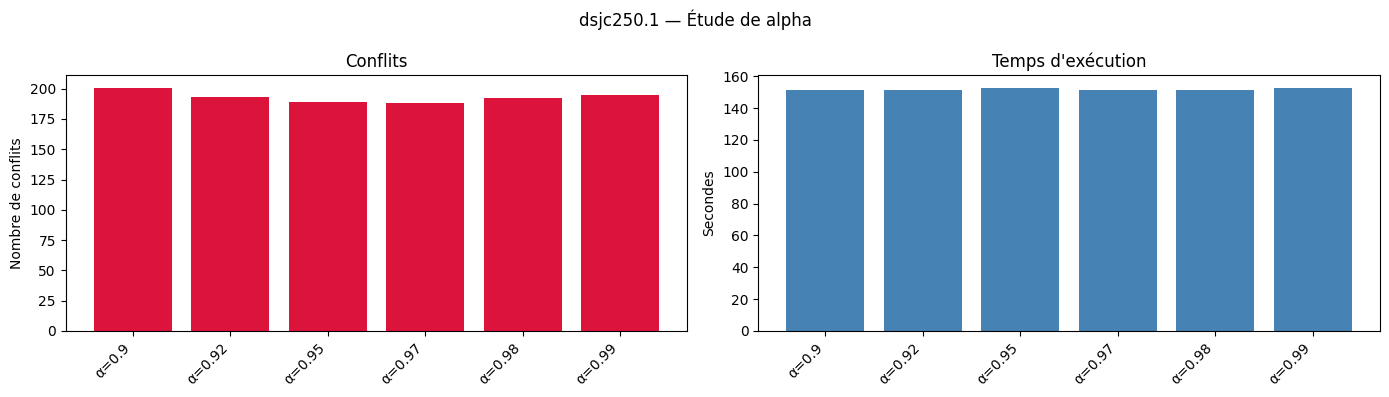


=== Meilleurs paramètres pour dsjc250.1 ===
- T_init : T=300 (Conflits: 187, Temps: 152.25s)
- max_cycles : Cycles=150 (Conflits: 187, Temps: 226.47s)
- iter : Iters=3000 (Conflits: 177, Temps: 454.21s)
- seuil : Seuil=10 (Conflits: 186, Temps: 151.85s)
- beta : β=0.9 (Conflits: 180, Temps: 151.36s)
- alpha : α=0.97 (Conflits: 188, Temps: 151.61s)


In [ ]:
import matplotlib.pyplot as plt

# Dictionnaire des meilleurs résultats connus
graphs_best = {
    "dsjc125.9": "44",
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "dsjc250.9": "72",
    "r250.5": "66/65",
    "r250.1": "8",
    "dsjc250.5": "28/?",
    "flat300_28_0": "28/28",
    "le450_25c": "25/25"
}

# Choisir un seul graphe
graph = "dsjc250.1"
best = graphs_best[graph]
matx, n = lire_graphe_triangulaire(f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col", is_url=True)
nb_couleurs = int(best.split("/")[0]) + 5

print(f"\n======= GRAPHE {graph} =======")

results = []

# T_init
for T_init in [10, 50, 100, 200, 300, 500, 1000]:
    sol, conflits, temps = recuit_simule_rechauffement(
        matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,
        T_init=T_init, alpha=0.95, beta=0.8,
        iter_par_cycle=1000, max_cycles=100, seuil_rechauffement=15
    )
    results.append({"param": "T_init", "label": f"T={T_init}", "conflicts": conflits, "time": temps})

# alpha
for alpha in [0.90, 0.92, 0.95, 0.97, 0.98, 0.99]:
    sol, conflits, temps = recuit_simule_rechauffement(
        matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,
        T_init=100.0, alpha=alpha, beta=0.8,
        iter_par_cycle=1000, max_cycles=100, seuil_rechauffement=15
    )
    results.append({"param": "alpha", "label": f"α={alpha}", "conflicts": conflits, "time": temps})

# beta
for beta in [0.6, 0.7, 0.75, 0.8, 0.85, 0.9]:
    sol, conflits, temps = recuit_simule_rechauffement(
        matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,
        T_init=100.0, alpha=0.95, beta=beta,
        iter_par_cycle=1000, max_cycles=100, seuil_rechauffement=15
    )
    results.append({"param": "beta", "label": f"β={beta}", "conflicts": conflits, "time": temps})

# iter_par_cycle
for iterations in [500, 1000, 1500, 2000, 3000]:
    sol, conflits, temps = recuit_simule_rechauffement(
        matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,
        T_init=100.0, alpha=0.95, beta=0.8,
        iter_par_cycle=iterations, max_cycles=100, seuil_rechauffement=15
    )
    results.append({"param": "iter", "label": f"Iters={iterations}", "conflicts": conflits, "time": temps})

# max_cycles
for max_c in [50, 100, 150, 200, 300]:
    sol, conflits, temps = recuit_simule_rechauffement(
        matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,
        T_init=100.0, alpha=0.95, beta=0.8,
        iter_par_cycle=1000, max_cycles=max_c, seuil_rechauffement=15
    )
    results.append({"param": "max_cycles", "label": f"Cycles={max_c}", "conflicts": conflits, "time": temps})

# seuil_rechauffement
for seuil in [5, 8, 10, 12, 15, 18, 20]:
    sol, conflits, temps = recuit_simule_rechauffement(
        matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,
        T_init=100.0, alpha=0.95, beta=0.8,
        iter_par_cycle=1000, max_cycles=100, seuil_rechauffement=seuil
    )
    results.append({"param": "seuil", "label": f"Seuil={seuil}", "conflicts": conflits, "time": temps})

# ===== Barplots par paramètre =====
params = set(r["param"] for r in results)

for param in params:
    param_results = [r for r in results if r["param"] == param]
    labels = [r["label"] for r in param_results]
    conflits = [r["conflicts"] for r in param_results]
    temps = [r["time"] for r in param_results]

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{graph} — Étude de {param}")

    axs[0].bar(labels, conflits, color='crimson')
    axs[0].set_title("Conflits")
    axs[0].set_xticklabels(labels, rotation=45, ha='right')
    axs[0].set_ylabel("Nombre de conflits")

    axs[1].bar(labels, temps, color='steelblue')
    axs[1].set_title("Temps d'exécution")
    axs[1].set_xticklabels(labels, rotation=45, ha='right')
    axs[1].set_ylabel("Secondes")

    plt.tight_layout()
    plt.show()

# ===== Meilleurs paramètres =====
print(f"\n=== Meilleurs paramètres pour {graph} ===")
for param in params:
    candidates = [r for r in results if r["param"] == param]
    best = min(candidates, key=lambda r: r["conflicts"])
    print(f"- {param} : {best['label']} (Conflits: {best['conflicts']}, Temps: {best['time']:.2f}s)")

# Tabu Search

In [37]:
import time
import random
from collections import deque

def get_best_neighbor(current_coloring, lower_tri_matrix, tabu_set, current_conflicts, current_colors):
    """
    Finds the best neighbor by evaluating moves incrementally using lower triangular matrix.
    """
    n_vertices = len(current_coloring)
    best_coloring = None
    best_conflicts = current_conflicts
    best_colors = current_colors
    improved = False

    # Try moves that reduce conflicts or number of colors
    for i in range(n_vertices):
        original_color = current_coloring[i]
        current_color_set = set(current_coloring)

        # Evaluate changing to existing colors first
        for color in current_color_set:
            if color == original_color:
                continue

            # Calculate conflict change for this move using lower triangular matrix
            conflict_change = 0
            # Check row i (connections to vertices j < i)
            for j in range(i):
                if lower_tri_matrix[i][j] == 1:
                    if current_coloring[j] == original_color:
                        conflict_change -= 1
                    if current_coloring[j] == color:
                        conflict_change += 1
            # Check column i (connections to vertices j > i)
            for j in range(i+1, n_vertices):
                if lower_tri_matrix[j][i] == 1:
                    if current_coloring[j] == original_color:
                        conflict_change -= 1
                    if current_coloring[j] == color:
                        conflict_change += 1

            new_conflicts = current_conflicts + conflict_change
            new_colors = current_colors if color in current_color_set else current_colors + 1

            # Check if this move is better and not tabu
            new_coloring = list(current_coloring)
            new_coloring[i] = color
            move_tuple = tuple(new_coloring)

            if (new_conflicts < best_conflicts or
                (new_conflicts == best_conflicts and new_colors < best_colors)):
                if move_tuple not in tabu_set:
                    best_coloring = new_coloring
                    best_conflicts = new_conflicts
                    best_colors = new_colors
                    improved = True

        # Also consider assigning a new color
        new_color = max(current_color_set) + 1 if current_color_set else 0
        conflict_change = 0
        # Check row i (connections to vertices j < i)
        for j in range(i):
            if lower_tri_matrix[i][j] == 1 and current_coloring[j] == original_color:
                conflict_change -= 1
        # Check column i (connections to vertices j > i)
        for j in range(i+1, n_vertices):
            if lower_tri_matrix[j][i] == 1 and current_coloring[j] == original_color:
                conflict_change -= 1

        new_conflicts = current_conflicts + conflict_change
        new_colors = current_colors + 1
        new_coloring = list(current_coloring)
        new_coloring[i] = new_color
        move_tuple = tuple(new_coloring)

        if (new_conflicts < best_conflicts or
            (new_conflicts == best_conflicts and new_colors < best_colors)):
            if move_tuple not in tabu_set:
                best_coloring = new_coloring
                best_conflicts = new_conflicts
                best_colors = new_colors
                improved = True

    return best_coloring, best_conflicts, best_colors, improved

def tabu_search(lower_tri_matrix, n_iter=100, max_tabu_size=10, patience=10):
    """
    Optimized Tabu Search for graph coloring using lower triangular adjacency matrix.

    Args:
        lower_tri_matrix (list of lists): Lower triangular adjacency matrix of the graph.
        n_iter (int): Maximum number of iterations.
        max_tabu_size (int): Maximum size of tabu list.
        patience (int): Number of iterations without improvement before early stopping.

    Returns:
        tuple: (best_coloring, best_number_colors, runtime)
    """
    start = time.time()
    n_vertices = len(lower_tri_matrix)

    # Initialize with greedy coloring using lower triangular matrix
    current_coloring = [0] * n_vertices
    for i in range(n_vertices):
        used_colors = set()
        # Check connections to vertices j < i (row i)
        for j in range(i):
            if lower_tri_matrix[i][j] == 1:
                used_colors.add(current_coloring[j])
        # Check connections to vertices j > i (column i)
        for j in range(i+1, n_vertices):
            if lower_tri_matrix[j][i] == 1:
                used_colors.add(current_coloring[j])
        # Assign smallest available color
        for color in range(n_vertices):
            if color not in used_colors:
                current_coloring[i] = color
                break

    # Calculate initial conflicts using lower triangular matrix
    current_conflicts = 0
    for i in range(n_vertices):
        # Check row i (connections to vertices j < i)
        for j in range(i):
            if lower_tri_matrix[i][j] == 1 and current_coloring[i] == current_coloring[j]:
                current_conflicts += 1
        # Column i is covered by other rows, so we don't need to check it here

    current_colors = len(set(current_coloring))
    best_coloring = list(current_coloring)
    best_conflicts = current_conflicts
    best_colors = current_colors

    # Use deque and set for efficient tabu list operations
    tabu_queue = deque(maxlen=max_tabu_size)
    tabu_set = set()

    no_improvement_count = 0

    for iteration in range(n_iter):
        # Find best neighbor
        neighbor, new_conflicts, new_colors, improved = get_best_neighbor(
            current_coloring, lower_tri_matrix, tabu_set, current_conflicts, current_colors)

        if not improved:
            # If no improving move found, select a random non-tabu move
            for _ in range(min(10, n_vertices)):  # Try up to 10 random moves
                i = random.randint(0, n_vertices-1)
                original_color = current_coloring[i]
                possible_colors = [c for c in range(current_colors+1) if c != original_color]
                if not possible_colors:
                    continue
                new_color = random.choice(possible_colors)

                new_coloring = list(current_coloring)
                new_coloring[i] = new_color
                move_tuple = tuple(new_coloring)

                if move_tuple not in tabu_set:
                    # Calculate conflicts for this move using lower triangular matrix
                    conflict_change = 0
                    # Check row i (connections to vertices j < i)
                    for j in range(i):
                        if lower_tri_matrix[i][j] == 1:
                            if current_coloring[j] == original_color:
                                conflict_change -= 1
                            if current_coloring[j] == new_color:
                                conflict_change += 1
                    # Check column i (connections to vertices j > i)
                    for j in range(i+1, n_vertices):
                        if lower_tri_matrix[j][i] == 1:
                            if current_coloring[j] == original_color:
                                conflict_change -= 1
                            if current_coloring[j] == new_color:
                                conflict_change += 1

                    neighbor = new_coloring
                    new_conflicts = current_conflicts + conflict_change
                    new_colors = current_colors if new_color < current_colors else current_colors + 1
                    improved = True
                    break

        if not improved:
            break  # No valid moves left

        # Update current solution
        current_coloring = neighbor
        current_conflicts = new_conflicts
        current_colors = new_colors

        # Update tabu list
        move_tuple = tuple(current_coloring)
        if len(tabu_queue) == max_tabu_size:
            old_move = tabu_queue.popleft()
            tabu_set.remove(old_move)
        tabu_queue.append(move_tuple)
        tabu_set.add(move_tuple)

        # Update best solution
        if (current_conflicts < best_conflicts or
            (current_conflicts == best_conflicts and current_colors < best_colors)):
            best_coloring = list(current_coloring)
            best_conflicts = current_conflicts
            best_colors = current_colors
            no_improvement_count = 0
        else:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                break  # Early stopping

    return best_coloring, best_conflicts, time.time() - start

# Différences entre les variantes du récuit simulé

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


data = {
    "Critère": [
        "Nom complet",
        "Principe général",
        "Paramètres clés",
        "Réglage (fine-tuning)",
        "Adaptation dynamique",
        "Parallelisme",
        "Avantages",
        "Inconvénients",
        "Quand l'utiliser",
        "Références"
    ],

    "RS Classique": [
        "Recuit Simulé (Simulated Annealing)",
        "Diminue progressivement la température pour échapper aux optima locaux.",
        "Température initiale (T0), taux de décroissance (alpha), nombre d’itérations par température.",
        "T0 élevé, alpha ≈ 0.95-0.99, ajuster selon la taille du problème.",
        "Non",
        "Non",
        "Simple, robuste, bonne exploration initiale.",
        "Peut se coincer si mal paramétré, lent.",
        "Problèmes de petite à moyenne taille ou pour comparer.",
        "[Kirkpatrick et al., 1983], [Aarts & Korst, 1989]"
    ],

    "RS Adaptatif": [
        "Recuit Simulé Adaptatif (Adaptive SA)",
        "Paramètres évoluent dynamiquement en fonction de la qualité de la recherche.",
        "T, taux de réussite, fenêtre de contrôle adaptatif.",
        "Auto-ajustement basé sur taux d’acceptation (20%-60%).",
        "Oui",
        "Non",
        "Meilleure robustesse, moins sensible aux paramètres initiaux.",
        "Plus complexe à implémenter.",
        "En cas d’incertitude sur le tuning, problèmes bruités.",
        "[Ben-Ameur, 2004], [Connolly, 1990]"
    ],

    "RS Parallèle": [
        "Recuit Simulé Parallèle",
        "Exécute plusieurs RS en parallèle avec échanges d’information (ex: Island Model).",
        "Nb d’instances, schéma de communication, synchronicité.",
        "Synchronisation périodique entre threads ou îlots.",
        "Partiel (au niveau local de chaque RS)",
        "Oui",
        "Gain de vitesse, évite stagnation.",
        "Demande plus de ressources (CPU), design distribué.",
        "Pour des problèmes de grande taille, HPC.",
        "[Ingber, 1993], [Alvarez & Marti, 2010]"
    ],

    "RS à T Oscillante": [
        "Recuit Simulé à Température Oscillante",
        "Température monte puis redescend par cycles → échappe mieux aux minima.",
        "Amplitude, fréquence d’oscillation, T0.",
        "Amplitude ≈ 10%-30% de T0, cycles lents.",
        "Oui (oscillatoire)",
        "Non",
        "Sort facilement des minima locaux, explore mieux.",
        "Peut ne pas converger rapidement, tuning délicat.",
        "Problèmes très piégeux avec de nombreux optima locaux.",
        "[Matos & Oliveira, 2001], [Lundy & Mees, 1986]"
    ]
}

df = pd.DataFrame(data)
df.set_index("Critère", inplace=True)
df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,RS Classique,RS Adaptatif,RS Parallèle,RS à T Oscillante
Critère,,,,
Nom complet,Recuit Simulé (Simulated Annealing),Recuit Simulé Adaptatif (Adaptive SA),Recuit Simulé Parallèle,Recuit Simulé à Température Oscillante
Principe général,Diminue progressivement la température pour échapper aux optima locaux.,Paramètres évoluent dynamiquement en fonction de la qualité de la recherche.,Exécute plusieurs RS en parallèle avec échanges d’information (ex: Island Model).,Température monte puis redescend par cycles → échappe mieux aux minima.
Paramètres clés,"Température initiale (T0), taux de décroissance (alpha), nombre d’itérations par température.","T, taux de réussite, fenêtre de contrôle adaptatif.","Nb d’instances, schéma de communication, synchronicité.","Amplitude, fréquence d’oscillation, T0."
Réglage (fine-tuning),"T0 élevé, alpha ≈ 0.95-0.99, ajuster selon la taille du problème.",Auto-ajustement basé sur taux d’acceptation (20%-60%).,Synchronisation périodique entre threads ou îlots.,"Amplitude ≈ 10%-30% de T0, cycles lents."
Adaptation dynamique,Non,Oui,Partiel (au niveau local de chaque RS),Oui (oscillatoire)
Parallelisme,Non,Non,Oui,Non
Avantages,"Simple, robuste, bonne exploration initiale.","Meilleure robustesse, moins sensible aux paramètres initiaux.","Gain de vitesse, évite stagnation.","Sort facilement des minima locaux, explore mieux."
Inconvénients,"Peut se coincer si mal paramétré, lent.",Plus complexe à implémenter.,"Demande plus de ressources (CPU), design distribué.","Peut ne pas converger rapidement, tuning délicat."
Quand l'utiliser,Problèmes de petite à moyenne taille ou pour comparer.,"En cas d’incertitude sur le tuning, problèmes bruités.","Pour des problèmes de grande taille, HPC.",Problèmes très piégeux avec de nombreux optima locaux.


# Comparaison entre le temps d execution et le nombre de couleurs sur differentes benchmarks par differentes variantes du RS

In [ ]:
# Dictionnaire des graphes et leurs bornes chromatiques connues
graphs_best = {
    "dsjc125.9": "44",
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "dsjc250.9": "72",
    "r250.5": "66/65",
    "r250.1": "8",
    "dsjc250.5": "28/?",
    "flat300_28_0": "28/28",
    "le450_25c": "25/25"
}

# Pour stocker les résultats
execution_times = {
    "recuit_simule": [],
    "recuit_adaptatif": [],
    "rechauffement": [],
    "parallel": [],
    "tabu_search": []
}
color_counts = {
    "recuit_simule": [],
    "recuit_adaptatif": [],
    "rechauffement": [],
    "parallel": [],
    "tabu_search": []
}

graph_names = []

# Lancer les algos sur chaque graphe
for graph, best in graphs_best.items():
    print("\n=== GRAPH:", graph, "===")
    graph_names.append(graph)

    matx, n = lire_graphe_triangulaire(
        f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col",
        is_url=True
    )
    nb_couleurs = int(best.split("/")[0]) + 5

    # --- Récuit simple
    sol, conflits, _, temps = recuit_simule(adj_matrix=matx,num_vertices=n, chromatic_number=nb_couleurs, initial_temp=1000,cooling_rate=0.003,max_iterations=10000)
    execution_times["recuit_simule"].append(temps)
    color_counts["recuit_simule"].append(len(set(sol)))

    # --- Récuit adaptatif
    sol, conflits, temps = recuit_simule_adaptatif(  adj_matrix=matx, num_vertices=n,chromatic_number=nb_couleurs, T_initial=100, alpha=0.9 )
    execution_times["recuit_adaptatif"].append(temps)
    color_counts["recuit_adaptatif"].append(len(set(sol)))

    # --- Récuit avec réchauffement
    sol, conflits, temps = recuit_simule_rechauffement( matrice=matx, nb_sommets=n, nb_couleurs=nb_couleurs,  T_init=100.0,  alpha=0.95,  beta=0.8,  iter_par_cycle=1000,  max_cycles=100,  seuil_rechauffement=15 )
    execution_times["rechauffement"].append(temps)
    color_counts["rechauffement"].append(len(set(sol)))

    # --- Récuit parallèle
    sol, conflits, temps = parallel_simulated_annealing_cooperative(adj_matrix=matx,num_vertices=n,chromatic_number=nb_couleurs,initial_temp=100,cooling_rate=0.003,num_workers=4 )
    execution_times["parallel"].append(temps)
    color_counts["parallel"].append(len(set(sol)))

    # --- Tabu search
    sol, conflits, temps = tabu_search(matx)
    execution_times["tabu_search"].append(temps)
    color_counts["tabu_search"].append(len(set(sol)))




=== GRAPH: dsjc125.9 ===

=== GRAPH: dsjc125.1 ===

=== GRAPH: dsjc250.1 ===

=== GRAPH: dsjc250.9 ===

=== GRAPH: r250.5 ===

=== GRAPH: r250.1 ===

=== GRAPH: dsjc250.5 ===

=== GRAPH: flat300_28_0 ===

=== GRAPH: le450_25c ===


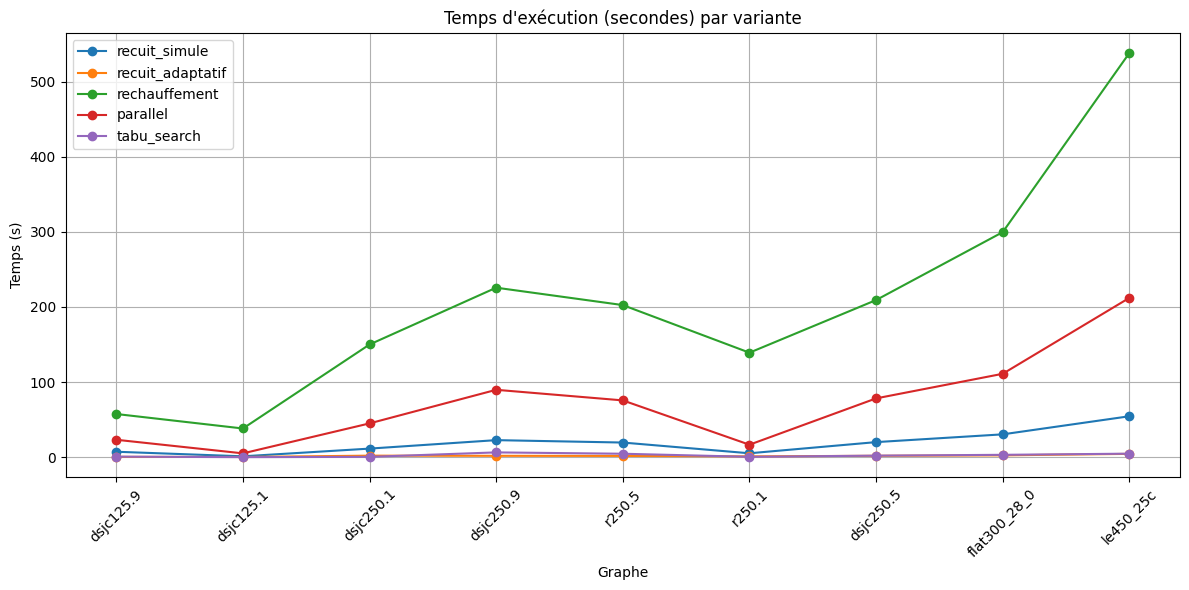

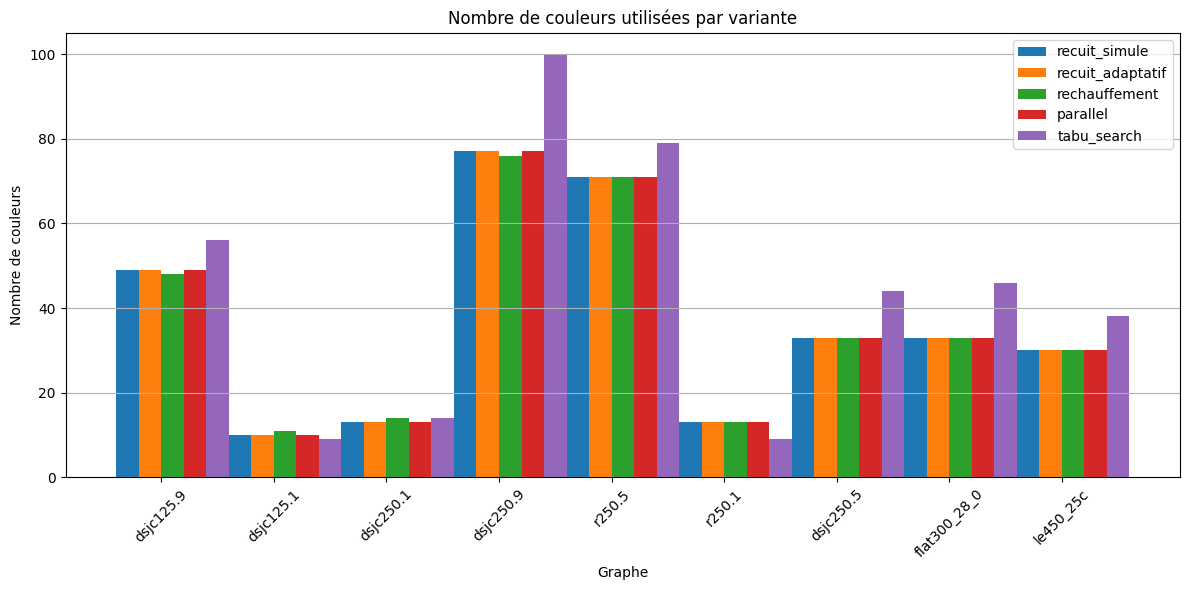

In [ ]:
# ============ AFFICHAGE ============
# 1. Temps d’exécution
plt.figure(figsize=(12, 6))
for algo, times in execution_times.items():
    plt.plot(graph_names, times, marker='o', label=algo)
plt.title("Temps d'exécution (secondes) par variante")
plt.xlabel("Graphe")
plt.ylabel("Temps (s)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# 2. Nombre de couleurs utilisées (Bar Graphs)
plt.figure(figsize=(12, 6))

algorithms = list(color_counts.keys())
x = np.arange(len(graph_names))  # the label locations
bar_width = 0.2  # Width of each bar

# Plot each algorithm's bars shifted
for i, algo in enumerate(algorithms):
    offset = (i - 1.5) * bar_width  # center the bars around each graph
    plt.bar(x + offset, color_counts[algo], width=bar_width, label=algo)

plt.title("Nombre de couleurs utilisées par variante")
plt.xlabel("Graphe")
plt.ylabel("Nombre de couleurs")
plt.xticks(x, graph_names, rotation=45)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Comparaison entre les metaheuristiques et heuristiques
la meilleure heuristique etant dsatur, on va la comparer avec la meilleure metaheuristique le rs adaptatif

In [19]:
def get_neighbors(node, matrice_triangulaire,n):
        """
        Retourne l'ensemble des voisins du nœud 'node' en utilisant la matrice triangulaire.
        Pour un nœud i, les voisins sont ceux :
          - Dans la même ligne pour les indices j < i (si matrice[i][j] == 1)
          - Dans les lignes suivantes pour lesquels le nœud i apparaît (si matrice[k][i] == 1 pour k > i)
        """
        neighbors = set()
        # Pour les indices j < node, vérifier la ligne 'node'
        for j in range(node):
            if matrice_triangulaire[node][j] == 1:
                neighbors.add(j)
        # Pour les indices > node, le nœud 'node' se trouve en colonne dans la ligne k
        for k in range(node + 1, n):
            if matrice_triangulaire[k][node] == 1:
                neighbors.add(k)
        return neighbors

def dsatur(matrice_triangulaire):
  start = time.time()
  n = len(matrice_triangulaire)
  voisins = {i: get_neighbors(i, matrice_triangulaire,n) for i in range (n)}
  coloring = [None]*n # affectation initial
  ensemble_saturation = [set() for _ in range(n)] #initialisation des ensembles de saturation de chaque noeud
  degre = [len(voisins[i]) for i in range(n)] # Use a list, not a set
  # tantque on n'a pas fini de colorier otus les noeuds
  while any(color is None for color in coloring): # Loop until all nodes are colored
    non_colories = [i for i in range(n) if coloring[i] is None]
    if not non_colories:
          break
    chosen = max(non_colories, key=lambda x: (len(ensemble_saturation[x]), degre[x]))
    used_colors = {coloring[v] for v in voisins[chosen] if coloring[v] is not None}
    color = 0
    while color in used_colors:
      color += 1
    coloring[chosen] = color
    for v in voisins[chosen]:
        if coloring[v] is None:
            ensemble_saturation[v].add(color)
  chromatic_number = max(coloring) + 1 if coloring else 0
  temps = time.time() - start
  return chromatic_number, coloring, temps

In [23]:
graphs_bench = {
    "dsjc125.1": "5",
    "dsjc250.1": "8",
    "r250.1": "8"
}

execution_times = {
    "dsatur": [],
    "recuit_adaptatif": []
}
color_counts = {
    "dsatur": [],
    "recuit_adaptatif": []
}
graph_names = []

for graph, best in graphs_bench.items():
    print("\n=== GRAPH:", graph, "===")
    graph_names.append(graph)

    matx, n = lire_graphe_triangulaire(
        f"https://cedric.cnam.fr/~porumbed/graphs/{graph}.col",
        is_url=True
    )
    nb_couleurs = int(best.split("/")[0]) + 5

    # --- DSATUR
    chroma_dsat, sol_dsat, time_dsat = dsatur(matx)
    execution_times["dsatur"].append(time_dsat)
    color_counts["dsatur"].append(chroma_dsat)

    # --- Récuit Simulé Adaptatif
    sol_rsa, conflits_rsa, time_rsa = recuit_simule_adaptatif(
        adj_matrix=matx,
        num_vertices=n,
        chromatic_number=nb_couleurs,
        T_initial=100,
        alpha=0.9
    )
    chroma_rsa = len(set(sol_rsa))
    execution_times["recuit_adaptatif"].append(time_rsa)
    color_counts["recuit_adaptatif"].append(chroma_rsa)


=== GRAPH: dsjc125.1 ===
[INFO] Conflits restants (7) → nouvelle tentative avec 11 couleurs.
[INFO] Conflits restants (7) → nouvelle tentative avec 12 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 13 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 14 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 15 couleurs.
[INFO] Conflits restants (4) → nouvelle tentative avec 16 couleurs.
[INFO] Conflits restants (2) → nouvelle tentative avec 17 couleurs.
[INFO] Conflits restants (1) → nouvelle tentative avec 18 couleurs.

=== GRAPH: dsjc250.1 ===
[INFO] Conflits restants (81) → nouvelle tentative avec 14 couleurs.
[INFO] Conflits restants (72) → nouvelle tentative avec 15 couleurs.
[INFO] Conflits restants (60) → nouvelle tentative avec 16 couleurs.
[INFO] Conflits restants (58) → nouvelle tentative avec 17 couleurs.
[INFO] Conflits restants (48) → nouvelle tentative avec 18 couleurs.
[INFO] Conflits restants (42) → nouvelle tentative avec 19 

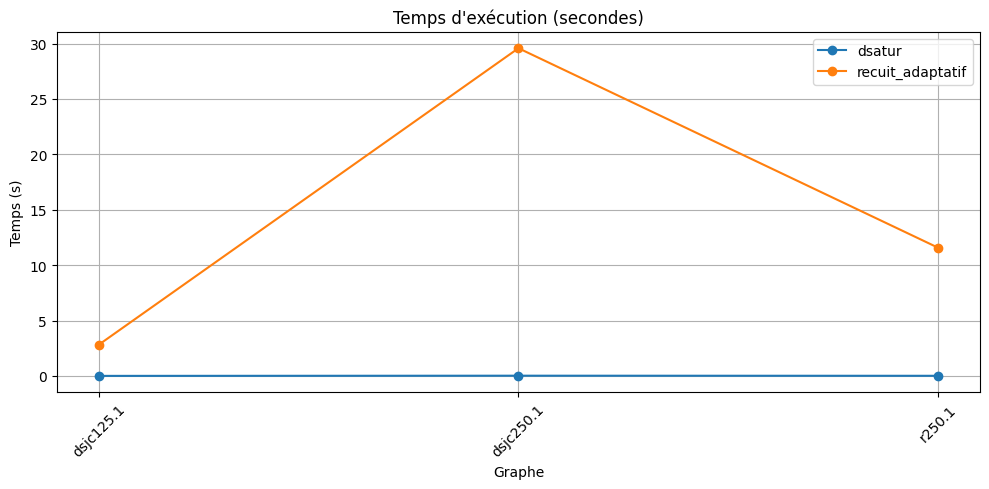

In [24]:
plt.figure(figsize=(10, 5))
for algo, times in execution_times.items():
    plt.plot(graph_names, times, marker='o', label=algo)

plt.title("Temps d'exécution (secondes)")
plt.xlabel("Graphe")
plt.ylabel("Temps (s)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

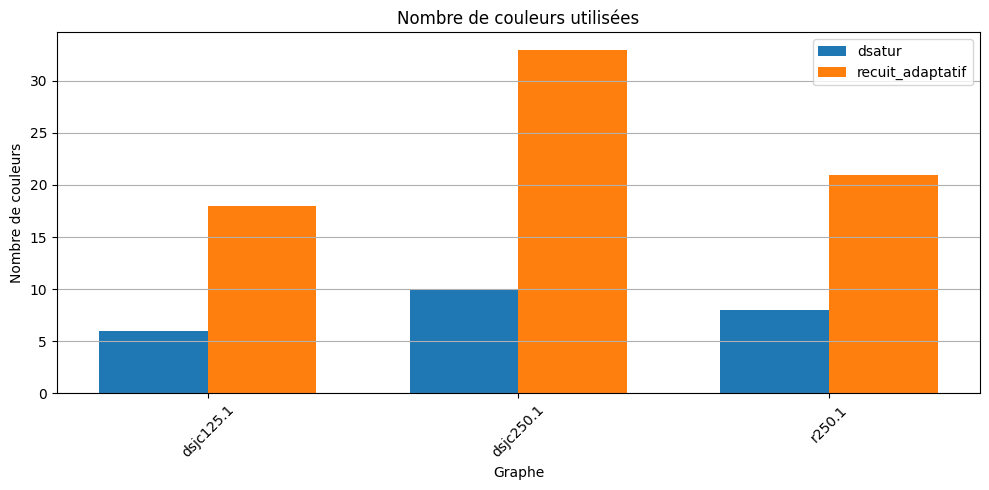

In [25]:
plt.figure(figsize=(10, 5))

algorithms = list(color_counts.keys())
x = np.arange(len(graph_names))
bar_width = 0.35

for i, algo in enumerate(algorithms):
    offset = (i - 0.5) * bar_width
    plt.bar(x + offset, color_counts[algo], width=bar_width, label=algo)

plt.title("Nombre de couleurs utilisées")
plt.xlabel("Graphe")
plt.ylabel("Nombre de couleurs")
plt.xticks(x, graph_names, rotation=45)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## Interpretation
Temps d'exécution :

DSATUR est plus rapide que le Récuit Adaptatif. Cela s'explique par sa nature gloutonne déterministe, alors que le RS Adaptatif explore l’espace de solutions de manière itérative et probabiliste.

Nombre de couleurs utilisées :

Le RS Adaptatif peut parfois utiliser moins de couleurs, surtout pour des graphes plus complexes où une exploration intelligente permet de trouver de meilleures solutions.
Ce phénomène s’explique en partie par la nature stochastique de RSA, qui autorise temporairement des conflits (colorations invalides) durant la recherche. Le mécanisme de refroidissement progressif tend à les réduire au fil des itérations, mais le rejet successif de configurations conflictuelles pour tendre vers une solution valide force parfois l’algorithme à augmenter artificiellement le nombre de couleurs, afin de sortir de ces situations conflictuelles.

DSATUR reste très compétitif, souvent proche ou égal au nombre chromatique connu.
